## Quadratic density modification
$$R(z) = r(z^2-z_0^2)-e^{-S(z_0)}$$

In [65]:
from scipy.integrate import solve_ivp
import numpy as np

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    directions_num = 2
    angles = np.linspace(0, 2*np.pi, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    phi_singular = kwargs.get("phi_singular", 5)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, phi_singular), t_eval=t_eval, method="BDF")
        sol.append(solution.y[0] + 1j * solution.y[1])
    return sol


def drift_func(z, sigma, lamb, pullback, phi_singular):
    action_z = sigma/2*z**2+lamb/4*z**4
    action_z0 = sigma/2*phi_singular**2+lamb/4*phi_singular**4

    if np.real(action_z) < 200: 
        if np.real(action_z0) < 0:
            num = z*(lamb*z**2+sigma-2*pullback*np.exp(action_z))*np.exp(action_z0)
            den = np.exp(action_z+action_z0)*pullback*(z**2-phi_singular**2)-np.exp(action_z)+np.exp(action_z0)
            out= num/den
            return out
        
        if np.real(action_z0) > 0:
            num = z*(lamb*z**2+sigma-2*pullback*np.exp(action_z))
            den = np.exp(action_z)*pullback*(z**2-phi_singular**2)-np.exp(action_z-action_z0)+1
            out= num/den
            return out
        
    elif np.real(action_z) > np.log(np.abs((sigma+lamb*z**2)/pullback))+30:
        out = -2*pullback*z / (pullback*(z**2-phi_singular**2)+np.exp(-action_z)-np.exp(-action_z0))
        return out

    print('AUTSCH!')
    return np.inf

drift_func = np.vectorize(drift_func)


def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_50468/3365628667.py:59: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_50468/3365628667.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


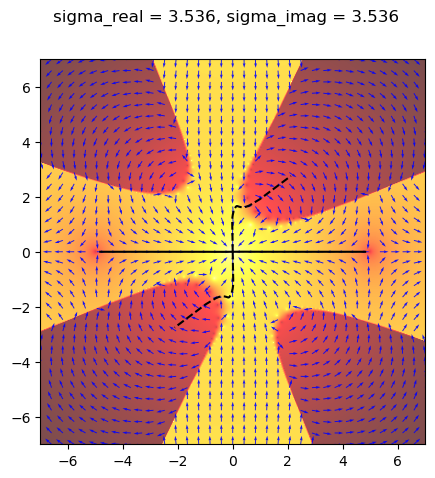

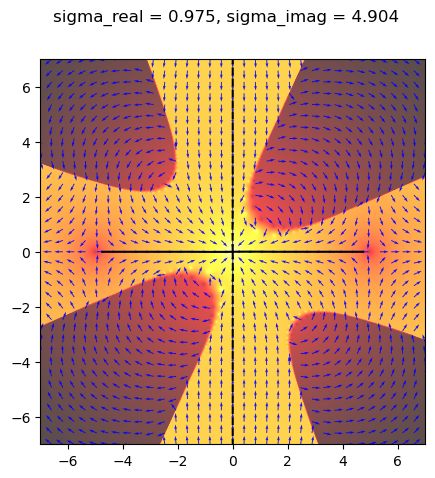

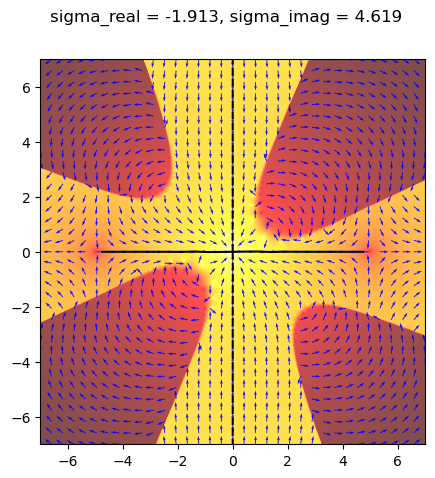

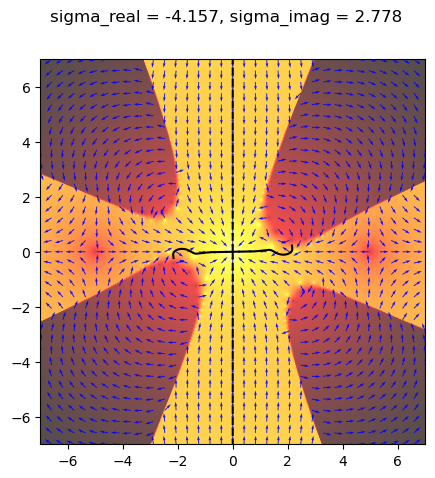

In [66]:

lamb = 1
sigma_abs = 5

start_angle = np.pi/4
stop_angle = np.pi

num = 4
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

phi_singular = 5
pullback = 100


import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 50000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility
    # y_range = ax.get_ylim()

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 50000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black', ls = '--')  # Set transparency for better visibility

    x_range = (-7, 7)
    y_range = (-7, 7)
    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    fig.show()
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_50468/2612002797.py:60: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_50468/2612002797.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


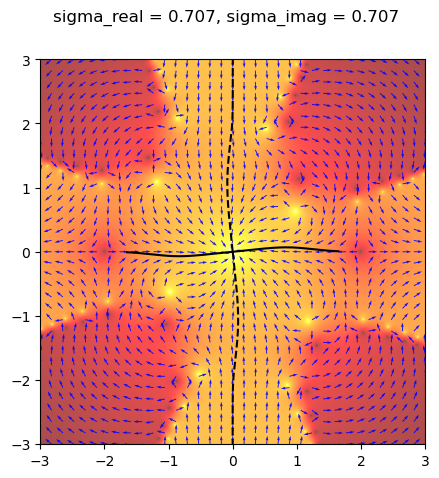

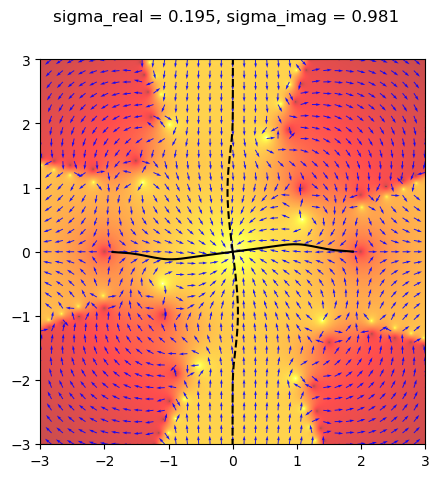

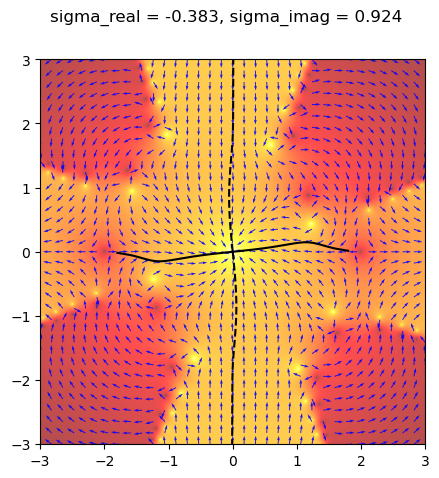

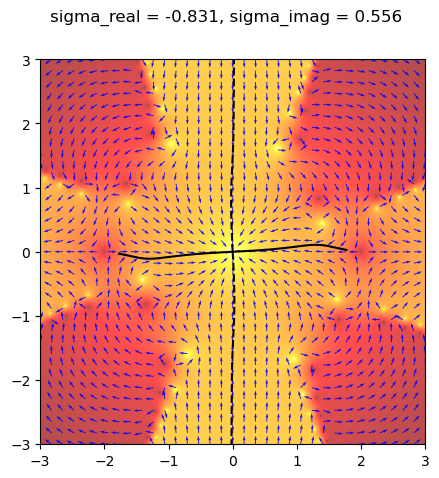

In [70]:


lamb = 1
sigma_abs = 1

start_angle = np.pi/4
stop_angle = np.pi

num = 4
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

phi_singular = 2
pullback = 2



import matplotlib.pyplot as plt

for idx_sig, sigma in enumerate(sigma_vals):

    fig, ax = plt.subplots(1, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")

    # stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 80000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black')  # Set transparency for better visibility
    # y_range = ax.get_ylim()

    # stable
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 80000), t_points=1000000, sigma = sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax.plot(sol.real, sol.imag, color = 'black', ls = '--')  # Set transparency for better visibility

    x_range = (-3, 3)
    y_range = (-3, 3)
    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift_func(Z, sigma=sigma, lamb=lamb, pullback=pullback, phi_singular=phi_singular)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
    fig.show()
    ax.set_ylim(*y_range)
    ax.set_xlim(*x_range)

In [4]:
from scipy.integrate import solve_ivp
import numpy as np

def solve_floweq(flow_equation_stable, flow_equation_unstable, crit_point, epsilon = 0.001, t_span = (0, 10), t_points=1000, events = None):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol_stable = []
    sol_unstable = []
    directions_num = 4
    angles = np.linspace(0+0.1, 2*np.pi+0.1, directions_num, endpoint=False)

    for  perturb in epsilon*np.exp(1j*angles):
        cp_0 = crit_point + perturb
        
        solution = solve_ivp(flow_equation_stable, t_span, [cp_0], t_eval=t_eval, method="RK45", events=events)
        z_values = solution.y[0]
        sol_stable.append(z_values)

        solution = solve_ivp(flow_equation_unstable, t_span, [cp_0], t_eval=t_eval, method="RK45", events=events)
        z_values = solution.y[0]
        sol_unstable.append(z_values)

    return sol_stable, sol_unstable

In [5]:
from scipy.integrate import solve_ivp
import numpy as np

def solve_floweq(flow_equation_stable, flow_equation_unstable, crit_point, epsilon = 0.001, t_span = (0, 10), t_points=1000, events = None):
    
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol_stable = []
    sol_unstable = []
    directions_num = 4
    angles = np.linspace(0+0.1, 2*np.pi+0.1, directions_num, endpoint=False)

    for  perturb in epsilon*np.exp(1j*angles):
        cp_0 = crit_point + perturb
        
        solution = solve_ivp(flow_equation_stable, t_span, [cp_0], t_eval=t_eval, method="RK45", events=events)
        z_values = solution.y[0]
        sol_stable.append(z_values)

        solution = solve_ivp(flow_equation_unstable, t_span, [cp_0], t_eval=t_eval, method="RK45", events=events)
        z_values = solution.y[0]
        sol_unstable.append(z_values)

    return sol_stable, sol_unstable

In [6]:
def drift(z, sigma, lamb):
    return z*sigma+z**3*lamb

def flow_equation_stable(t, z, sigma, lamb, r, z0):
    return +np.conj(drift(z, sigma, lamb))

def flow_equation_unstable(t, z, sigma, lamb, r, z0):
    return -np.conj(drift(z, sigma, lamb))

In [7]:
def drift_mod_func(z, sigma, lamb, r, z0):
    action_z = sigma/2*z**2+lamb/4*z**4
    action_z0 = sigma/2*z0**2+lamb/4*z0**4

    if np.real(action_z) < 200: 
        if np.real(action_z0) < 0:
            num = z*(lamb*z**2+sigma-2*r*np.exp(action_z))*np.exp(action_z0)
            den = np.exp(action_z+action_z0)*r*(z**2-z0**2)-np.exp(action_z)+np.exp(action_z0)
            # print("A")
            return num/den
        
        if np.real(action_z0) > 0:
            num = z*(lamb*z**2+sigma-2*r*np.exp(action_z))
            den = np.exp(action_z)*r*(z**2-z0**2)-np.exp(action_z-action_z0)+1
            # print("B")
            return num/den
        
    elif np.real(action_z) > np.log(np.abs((sigma+lamb*z**2)/r))+30:
        # print("C")
        return -2*r*z / (r*(z**2-z0**2)+np.exp(-action_z)-np.exp(-action_z0))
    
    print('AUTSCH!')
    return np.inf
    
drift_mod_func = np.vectorize(drift_mod_func)

def flow_equation_stable(t, z, sigma, lamb, r, z0):
    return +np.conj(drift_mod_func(z, sigma, lamb, r, z0))

def flow_equation_unstable(t, z, sigma, lamb, r, z0):
    return -np.conj(drift_mod_func(z, sigma, lamb, r, z0))


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_45122/1738183081.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


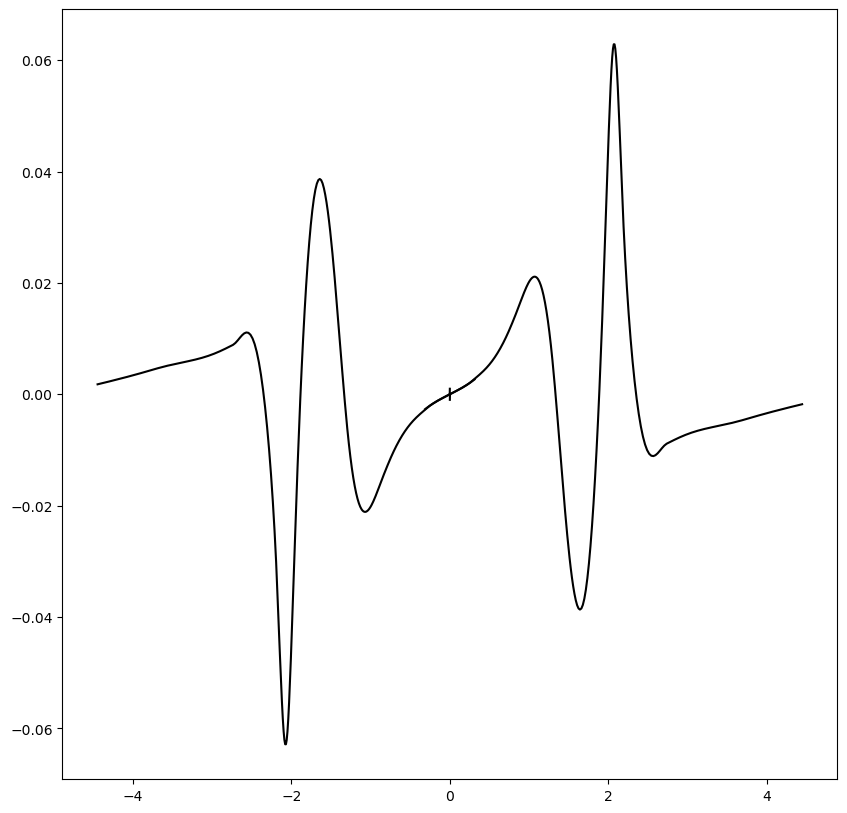

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots


lamb = 1
sigma_abs = 5
sigma_phase = np.pi*3/4
sigma = sigma_abs*np.exp(1j*sigma_phase)
r = 120
z0 = 5
stable, unstable = solve_floweq(lambda t, z: flow_equation_stable(t, z, sigma, lamb, r, z0), 
                                lambda t, z: flow_equation_unstable(t, z, sigma, lamb, r, z0), 
                                crit_point=0, t_span=(0, 100))

for init_data in stable:
    ax.plot(init_data.real, init_data.imag, color = 'black', ls = '-')

# for init_data in unstable:
#     ax.plot(init_data.real, init_data.imag, color = 'black', ls = '--')

# x_range = (-6, 6)
# y_range = (-6, 6)
# x = np.linspace(*x_range, 400)
# y = np.linspace(*y_range, 400)
# X, Y = np.meshgrid(x, y)
# Z = X + 1j * Y
# drift_values = drift_mod_func(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)
# mags = np.abs(drift_values)
# # threshold = 1e-1
# # mags[mags < threshold] = 0

# ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

# x = np.linspace(*x_range, 35)
# y = np.linspace(*y_range, 35)
# X, Y = np.meshgrid(x, y)
# Z = X + 1j * Y
# drift_values = -1*drift_mod_func(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)

# U = np.real(drift_values)
# V = np.imag(drift_values)
# mags = np.abs(drift_values)
# # threshold = 1e-1
# # mags[mags<threshold] = np.inf

# ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
fig.show()

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_45122/2037368174.py:47: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_45122/2037368174.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


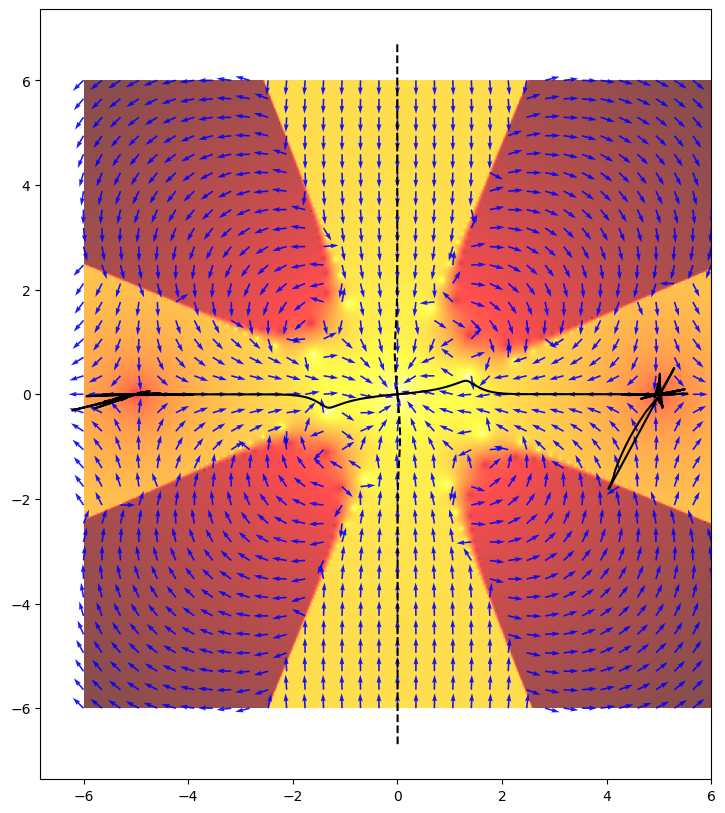

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots


lamb = 1
sigma_abs = 1
sigma_phase = np.pi*3/4
sigma = sigma_abs*np.exp(1j*sigma_phase)
r = 1.5
z0 = 5
stable, unstable = solve_floweq(lambda t, z: flow_equation_stable(t, z, sigma, lamb, r, z0), 
                                lambda t, z: flow_equation_unstable(t, z, sigma, lamb, r, z0), 
                                crit_point=0, t_span=(0, 100))

for init_data in stable:
    ax.plot(init_data.real, init_data.imag, color = 'black', ls = '-')

for init_data in unstable:
    ax.plot(init_data.real, init_data.imag, color = 'black', ls = '--')

x_range = (-6, 6)
y_range = (-6, 6)
x = np.linspace(*x_range, 400)
y = np.linspace(*y_range, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
drift_values = drift_mod_func(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)
mags = np.abs(drift_values)
# threshold = 1e-1
# mags[mags < threshold] = 0

ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

x = np.linspace(*x_range, 35)
y = np.linspace(*y_range, 35)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
drift_values = -1*drift_mod_func(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)

U = np.real(drift_values)
V = np.imag(drift_values)
mags = np.abs(drift_values)
# threshold = 1e-1
# mags[mags<threshold] = np.inf

ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
fig.show()

In [35]:
def drift_mod_func(z, sigma, lamb, r, z0):
    action_z = sigma/2*z**2+lamb/4*z**4
    action_z0 = sigma/2*z0**2+lamb/4*z0**4

    if np.real(action_z) < 200: 
        if np.real(action_z0) < 0:
            num = z*(lamb*z**2+sigma-2*r*np.exp(action_z))*np.exp(action_z0)
            den = np.exp(action_z+action_z0)*r*(z**2-z0**2)-np.exp(action_z)+np.exp(action_z0)
            # print("A")
            return num/den
        
        if np.real(action_z0) > 0:
            num = z*(lamb*z**2+sigma-2*r*np.exp(action_z))
            den = np.exp(action_z)*r*(z**2-z0**2)-np.exp(action_z-action_z0)+1
            # print("B")
            return num/den
        
    elif np.real(action_z) > np.log(np.abs((sigma+lamb*z**2)/r))+30:
        # print("C")
        return -2*r*z / (r*(z**2-z0**2)+np.exp(-action_z)-np.exp(-action_z0))
    
    print('AUTSCH!')
    return np.inf
    
drift_mod_func = np.vectorize(drift_mod_func)

def flow_equation_stable(t, z, sigma, lamb, r, z0):
    return +np.conj(drift_mod_func(z, sigma, lamb, r, z0))

def flow_equation_unstable(t, z, sigma, lamb, r, z0):
    return -np.conj(drift_mod_func(z, sigma, lamb, r, z0))


In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def thimble_plot(action=None, drift=None, crit_points=None, flow_equation=None, 
                sigma_abs=1, sigma_phase=np.pi/4,lamb_abs=1, lamb_phase=0,
                epsilon = 0.001, t_span = (0, 10),t_points=10000, 
                x_range = (-3, 3), y_range = (-3, 3), z0 = 1, r=1
                ):
    
    import numpy as np
    sigma = sigma_abs*np.exp(1j*sigma_phase)
    lamb = lamb_abs*np.exp(1j*lamb_phase)

    if action==None:
        def action(z, sigma, lamb):
            """Action S(z) = 1/2 * sigma * z^2 + lamb / 4 * z^4"""

            return 1/2 * sigma * z**2 + lamb / 4 * z**4
    if drift==None:
        def drift(z, sigma,lamb):
            """Derivative of the action with respect to z."""
            return sigma * z + lamb * z**3
        
    if crit_points==None:
        cp0 = -np.sqrt(-sigma / lamb)
        cp1 = 0
        cp2 = +np.sqrt(-sigma / lamb)
        crit_points = np.array([cp0, cp1, cp2])
        crit_points = np.array([0])

    if flow_equation==None:
        def flow_equation(t, z, sigma, lamb, factor):
            """The flow equation dz/dt = conjugate(S'(z))"""
            dz_dt = factor*np.conj(drift(z, sigma, lamb))
            return dz_dt
        
    t_eval = np.linspace(t_span[0], t_span[1], t_points)

    # Loop through each sigma value and corresponding subplot
    fig, ax = plt.subplots(1, figsize=(7, 7), sharex= True, sharey = True)
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
        
        # Plot the flow of Lefschetz Thimbles
    for cp in crit_points:
        for idx, perturb in enumerate(epsilon*np.exp(1j*np.linspace(0, 2*np.pi, 8, endpoint=False))):
            print(idx)
            cp_0 = cp + perturb
            factor = +1
            solution = solve_ivp(flow_equation, t_span, [cp_0], args=(r, sigma, lamb, factor), t_eval=t_eval, method="RK45")
            z_values = solution.y[0]
            ax.plot(z_values.real, z_values.imag, color='black')

            factor = -1
            solution = solve_ivp(flow_equation, t_span, [cp_0], args=(r, sigma, lamb, factor), t_eval=t_eval, method="RK45")
            z_values = solution.y[0]
            ax.plot(z_values.real, z_values.imag, color='black', ls='--')
        
    # Scatter plot the critical points
    ax.scatter(crit_points.real, crit_points.imag, color='red', zorder=5, label="critical points")
    
    # Create the vector field of the action
    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)

    # Add background heatmap for drift values
    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)
    mags = np.abs(drift_values)
    threshold = 1e-1
    mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    # Set plot details for each subplot
    fig.suptitle(f'σ = {np.round(sigma, decimals=2)}', fontsize=14)
    ax.set_xlabel('Re(z)', fontsize=12)
    ax.set_ylabel('Im(z)', fontsize=12)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)# S_derivative_real
    ax.set_aspect('equal', adjustable='box')

    # ax.set_xlim(*(val * 1.0001 for val in x_range))
    # ax.set_ylim(*(val * 1.0001 for val in y_range))

    from matplotlib.lines import Line2D

    handles, labels = plt.gca().get_legend_handles_labels()

    line_stable = Line2D([0], [0], label=r'$\mathcal{J}$', ls='-', color='black')
    line_unstable = Line2D([0], [0], label=r'$\mathcal{K}$', ls = '--', color='black')

    # add manual symbols to auto legend
    handles.extend([line_unstable, line_stable])

    ax.legend(handles=handles, bbox_to_anchor=(0, 1.01, 1, 0.2), fontsize = 10, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=0.5)
    fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9, hspace=0.0, wspace=0.0)

We want to artificially introduce zeros in the density by a additive modification of the action. 
$$
S \to \tilde{S} = \frac{\sigma}{2}z^2+\frac{\lambda}{4}z^4+\psi(z)\qquad \rho \to \tilde{\rho} = \rho + R(z)
$$
forcing $\tilde{\rho} = \tilde{S}$ gives
$$
\psi(z) = -\ln(1+R(z)e^{S})
$$

As an example, we want to generate a zero in $\tilde{\rho}$ at a finite $z = z_{0}$. 
This is achieved by setting $R(z) = -\rho(z_{0})$ resulting in 
$$
\psi(z) = -\ln\left( 1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right) \right)
$$
The drift is calculated
$$
\partial_{z}\tilde{S} = \partial_{z}S+\partial_{z}\psi= \partial_{z}S+\frac{\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}{1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}\partial_{z}S= \partial_{z}S\, \left[ 1+\frac{\exp{\{S(z)-S(z_{0})\}}}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$
Further simplifying
$$
\partial_{z}\tilde{S} = \partial_{z}S \, \left[ \frac{1}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$

In [37]:
from sympy import symbols, diff, Function, re, im, sqrt, exp, I
import sympy as sp
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = -exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))

drift_mod = sp.diff(action_mod, z).simplify()
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 + sigma)*exp(z_0**2*(lambda*z_0**2/2 + sigma))/(exp(z_0**2*(lambda*z_0**2/2 + sigma)) - exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2))

In [38]:
def action_mod_func(z, z0, r, sigma, lamb):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    out = action

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if overflow:
        out -= 1j*np.pi + delta_s
    else:
        out -= np.log(1-np.exp(delta_s))
    return out

action_mod_func = np.vectorize(action_mod_func)

In [39]:
def drift_mod_func(z, z0, r, sigma, lamb):
    drift = lamb * z**3 + sigma * z
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if delta_s == 0: return np.inf
    if overflow:
        out = -drift*np.exp(-delta_s)
    else:
        out = drift / (1-np.exp(delta_s))
    return out

drift_mod_func = np.vectorize(drift_mod_func)


0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:88: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)


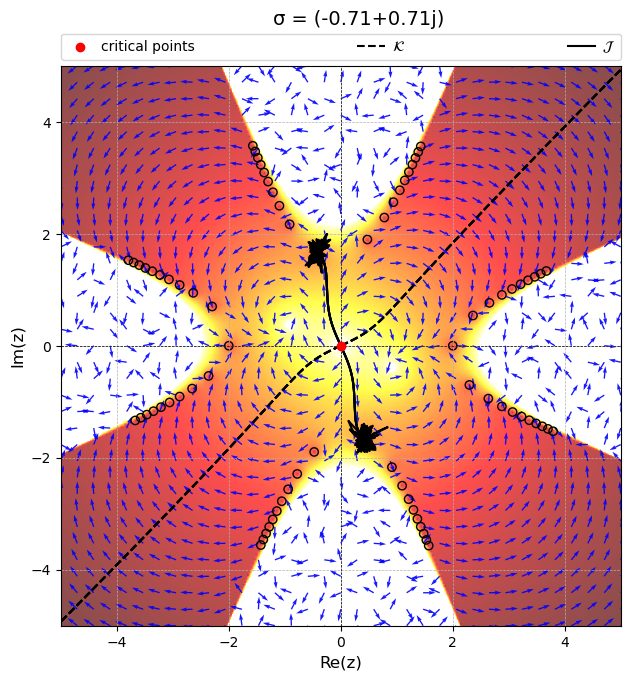

In [40]:
z0 = 2

def flow_equation(t, z, r, sigma, lamb, factor):
    drift =  drift_mod_func(z, z0, r, sigma, lamb)
    return factor*np.conj(drift)


sigma_phase=3*np.pi/4
lamb_phase=0
sigma_abs=1
lamb_abs=1
sigma = sigma_abs*np.exp(1j*sigma_phase)
lamb = lamb_abs*np.exp(1j*lamb_phase)
x_range = (-5, 5)
y_range = (-5, 5)
thimble_plot(action=action_mod_func, drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,10), x_range=x_range, y_range=y_range)

action_z_0 = sigma/2*z0**2 + lamb/4*z0**4
for k in range(-10, 10):
    c_k = (sigma / 2) * z0**2 + (lamb / 4) * z0**4 + 2 * np.pi * 1j * k

    u_plus = (-sigma + np.sqrt(sigma**2 + 4 * lamb * c_k)) / lamb
    u_minus = (-sigma - np.sqrt(sigma**2 + 4 * lamb * c_k)) / lamb

    z_plus_plus = np.sqrt(u_plus)
    z_plus_minus = -np.sqrt(u_plus)
    z_minus_plus = np.sqrt(u_minus)
    z_minus_minus = -np.sqrt(u_minus)

    z_solutions = np.array([z_plus_plus, z_plus_minus, z_minus_plus, z_minus_minus])
    plt.scatter(z_solutions.real, z_solutions.imag, color = 'black', facecolors='none', edgecolors='black')

Let's look at the modification 
$$
R(z) = r(z^2-z_0^2)-\rho(-S_0)
$$

In [41]:
from sympy import symbols, diff, Function, re, im, sqrt, exp
import sympy as sp
sigma_r, lamb_r = symbols('sigma_r, lambda_r', real=True)
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi', real=True)
sigma, lamb = sigma_r*exp(sp.I*sigma_phi), lamb_r*exp(sp.I*lamb_phi)
z_phi, z_r = symbols('z_phi, z_r', real=True)
z = z_r*exp(sp.I*z_phi)
z = symbols('z')
# sigma, lamb = symbols('sigma lambda')
action = sigma/2*z**2 + lamb/4*z**4

In [42]:
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = r*(z**2-z_0**2)-exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))
action_mod_func = sp.lambdify((z, z_0, sigma, lamb, r), action_mod, 'numpy')

drift_mod = sp.diff(action_mod, z).simplify()
drift_mod_func  = sp.lambdify((symbols('t z z_0 sigma lambda r')), drift_mod,  'numpy')
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 - 2*r*exp(lambda*z**4/4 + sigma*z**2/2) + sigma)*exp(lambda*z_0**4/4 + sigma*z_0**2/2)/(r*z**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - r*z_0**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - exp(lambda*z**4/4 + sigma*z**2/2) + exp(lambda*z_0**4/4 + sigma*z_0**2/2))

In [43]:
def drift_mod_func(z, z0, r, sigma, lamb):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    drift = sigma*z+lamb*z**3

    # case of action -> -inf
    threshold_log = 10
    if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
        out = drift*(1-np.exp(action-action_z_0))
    else:
        num = drift*np.exp(-action)-2*r*z
        den = r*(z**2-z0**2) - np.exp(-action_z_0)+ np.exp(-action)
        out = num/den
    # num = drift*np.exp(-action)-2*r*z
    # den = r*(z**2-z0**2) - np.exp(-action_z_0)+ np.exp(-action)
    # out = num/den
    return out

drift_mod_func = np.vectorize(drift_mod_func)

0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/44977733.py:8: RuntimeWarning: invalid value encountered in scalar divide
  if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:88: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)


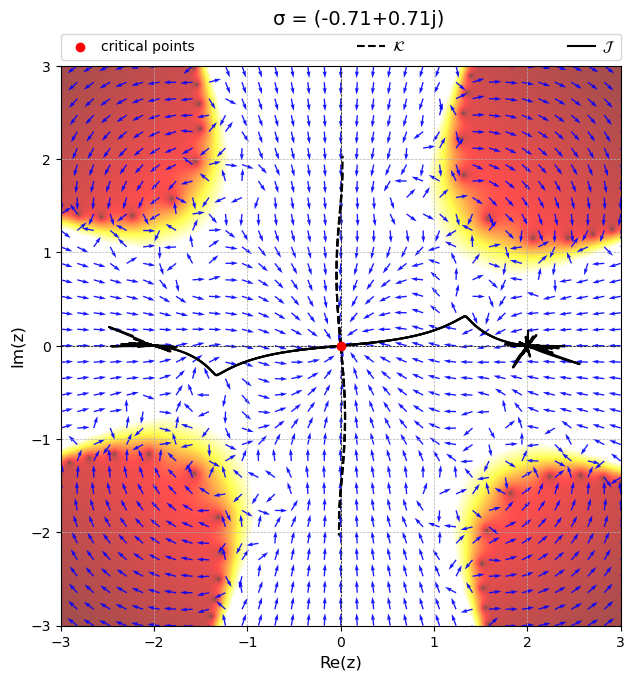

In [44]:
thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0=20, sigma_phase=np.pi*3/4, sigma_abs=sigma_abs, t_span=(0,11), x_range = (-3, 3), y_range=(-3, 3), r=1.4)


0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/44977733.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  out = num/den
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/44977733.py:8: RuntimeWarning: invalid value encountered in scalar divide
  if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:68: RuntimeWarning: invalid value encountered in multiply
  drift_values = -1*drift(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:88: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', c

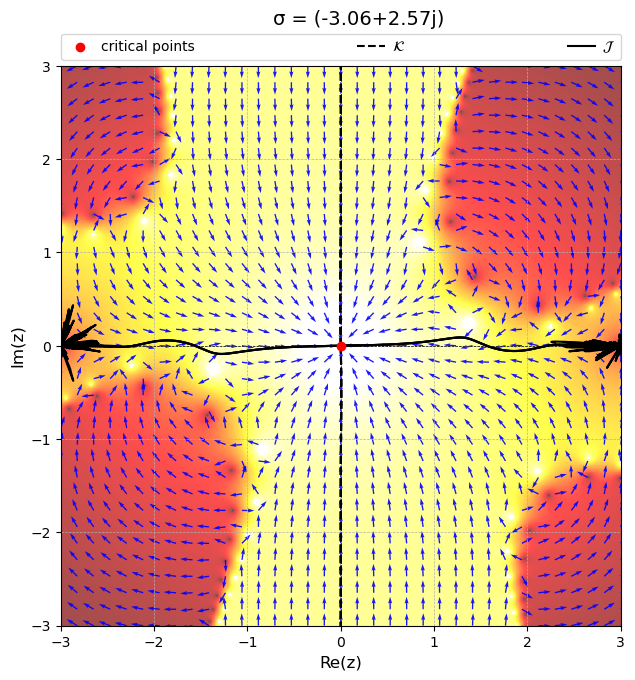

In [45]:
z0 = 3

def flow_equation(t, z, r, sigma, lamb, factor):
    drift =  drift_mod_func(z, z0, r, sigma, lamb)
    return factor*np.conj(drift)


sigma_phase=3/4*np.pi
lamb_phase=0
sigma_abs=4
lamb_abs=1
sigma = sigma_abs*np.exp(1j*sigma_phase)
lamb = lamb_abs*np.exp(1j*lamb_phase)
x_range = (-3, 3)
y_range = (-3, 3)

sigma = -3.06417777+2.57115044j
sigma_phase = np.angle(sigma)
# thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,420), x_range=x_range, y_range=y_range, r=1.5)
# thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,330), x_range=x_range, y_range=y_range, r=1.4)
thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, sigma_abs = 4, t_span=(0,40), x_range=x_range, y_range=y_range, r=35)
# thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,10), x_range=x_range, y_range=y_range, r=1.22)



In [46]:
interaction = 1
sigma_abs = 4

delta = 0.05
start_angle = np.pi/2
stop_angle = np.pi

num = 4
angles = np.linspace(start_angle, stop_angle, num)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))


0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/44977733.py:8: RuntimeWarning: invalid value encountered in scalar divide
  if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_60062/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)


KeyboardInterrupt: 

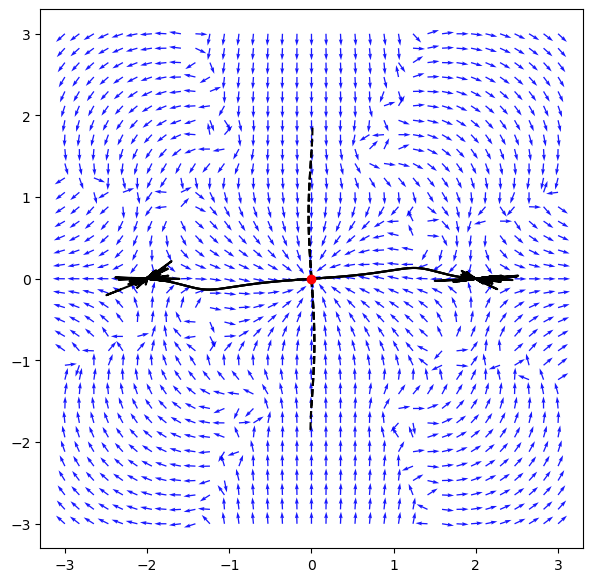

In [47]:
z0 = 2

def flow_equation(t, z, r, sigma, lamb, factor):
    drift =  drift_mod_func(z, z0, r, sigma, lamb)
    return factor*np.conj(drift)


sigma_phase=3/4*np.pi
lamb_phase=0
sigma_abs=1
lamb_abs=1
sigma = sigma_abs*np.exp(1j*sigma_phase)
lamb = lamb_abs*np.exp(1j*lamb_phase)
x_range = (-3, 3)
y_range = (-3, 3)
thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,12), x_range=x_range, y_range=y_range, r=2)
